In [16]:
# take a single feauture from the dataset and linear regression it

import numpy as np
from sklearn.linear_model import LinearRegression

data = np.load("fc7_features.npz")

X = data[data.files[0]] #takes the feutures
y = X[:, 1].reshape(-1, 1) #takes the outputs
X_single = X[:, 0].reshape(-1, 1)#makes sure a single feature column is taken from the dataset
# the code for linear regression
reg = LinearRegression() 
reg.fit(X_single, y)
y_train_pred = reg.predict(X_single)
print("Coefficient:", reg.coef_) # this is the slope, small- has weak positive presence , negative - decreases
print("Intercept:", reg.intercept_) # baseline value


Coefficient: [[-0.00096341]]
Intercept: [0.00931403]


In [17]:
#q2 calculate mse,rmse,mape and r2 scores

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

data = np.load("fc7_features.npz")

X = data[data.files[0]] #takes the features
y = X[:, 1].reshape(-1, 1)
X_single = X[:, 0].reshape(-1, 1) #takes only one of the features

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split( #x_single is used so that we use only one of the features 
    X_single, y, test_size=0.2, random_state=42 #0.2 means that 20% of the data will be used for testing and the rest for training, random split no is set so that evrytime u dont get a diffrent value
)

reg = LinearRegression()
reg.fit(X_train, y_train) #trains on train data
y_train_pred = reg.predict(X_train)
y_test_pred = reg.predict(X_test)

#TRAIN METRICS
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

#TEST METRICS
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

#results
print("TRAIN METRICS")
print("MSE:", mse_train)
print("RMSE:", rmse_train)
print("MAPE:", mape_train)
print("R2:", r2_train)

print("\nTEST METRICS")
print("MSE:", mse_test)
print("RMSE:", rmse_test)
print("MAPE:", mape_test)
print("R2:", r2_test)

TRAIN METRICS
MSE: 0.017979983240365982
RMSE: 0.1340894598406824
MAPE: 41957694898176.0
R2: 0.0006618499755859375

TEST METRICS
MSE: 9.271812450606376e-05
RMSE: 0.009629025106731406
MAPE: 40226122629120.0
R2: 0.0


In [20]:
#q3 do linear regress and calculate mse,rmse,mape and r2 scores for all

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

data = np.load("fc7_features.npz")

X1 = data[data.files[0]] #takes the features
y = X1[:, 0]
X = X1[:, 1:-1]#takes only one of the features

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split( 
    X, y, test_size=0.2, random_state=42 #0.2 means that 20% of the data will be used for testing and the rest for training, random split no is set so that evrytime u dont get a diffrent value
)

reg = LinearRegression()
reg.fit(X_train, y_train) #trains on train data
y_train_pred = reg.predict(X_train)
y_test_pred = reg.predict(X_test)

#TRAIN METRICS
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

#TEST METRICS
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

#results
print("Coefficient:", reg.coef_) # this is the slope, small- has weak positive presence , negative - decreases
print("Intercept:", reg.intercept_) # baseline value

print("\nTRAIN METRICS")
print("MSE:", mse_train)
print("RMSE:", rmse_train)
print("MAPE:", mape_train)
print("R2:", r2_train)

print("\nTEST METRICS")
print("MSE:", mse_test)
print("RMSE:", rmse_test)
print("MAPE:", mape_test)
print("R2:", r2_test)

Coefficient: [ 0.00407564  0.0220055   0.0159064  ...  0.00500926 -0.01923542
 -0.00100364]
Intercept: 0.28070557

TRAIN METRICS
MSE: 1.8872700277561272e-11
RMSE: 4.344272122871825e-06
MAPE: 8249350656.0
R2: 1.0

TEST METRICS
MSE: 1.7447596788406372
RMSE: 1.3208935153299213
MAPE: 2013892448354304.0
R2: 0.8559951782226562


In [21]:
# A4

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score 
from sklearn.metrics import calinski_harabasz_score 
from sklearn.metrics import davies_bouldin_score
from sklearn.preprocessing import StandardScaler

# Load NPZ file
data = np.load("fc7_features.npz")

# Check what arrays exist
print("Arrays inside file:", data.files)

# Usually first array = features
X = data[data.files[0]]

# If labels exist (optional, NOT used in clustering)
if len(data.files) > 1:
    y = data[data.files[1]]

print("Shape of X:", X.shape)


# Feature scaling (VERY IMPORTANT for K-means)
def scale_features(X):
    """
    Scales the feature matrix using StandardScaler
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled


# Apply K-means clustering
def apply_kmeans(X_scaled, n_clusters=2, random_state=0):
    """
    Applies K-means clustering
    """
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init="auto"
    )
    kmeans.fit(X_scaled)
    return kmeans


# Feature scaling
X_scaled = scale_features(X)

# Apply K-means clustering
kmeans = apply_kmeans(X_scaled, n_clusters=2, random_state=0)

# Cluster labels
cluster_labels = kmeans.labels_
print("Cluster labels:")
print(cluster_labels)

# Cluster centers
cluster_centers = kmeans.cluster_centers_
print("Cluster centers:")
print(cluster_centers)


Arrays inside file: ['features', 'labels', 'label_names']
Shape of X: (633, 4096)
Cluster labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0

In [22]:
# A5
def evaluate_clustering(X_scaled, labels):
    """Computes Silhouette, CH, and DB scores"""

    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    return sil, ch, db


sil_score, ch_score, db_score = evaluate_clustering(X_scaled, cluster_labels)

print("Silhouette Score:", sil_score)
print("Calinski-Harabasz Score:", ch_score)
print("Davies-Bouldin Index:", db_score)


Silhouette Score: 0.3277788460254669
Calinski-Harabasz Score: 4.183358669281006
Davies-Bouldin Index: 1.3786655938919392


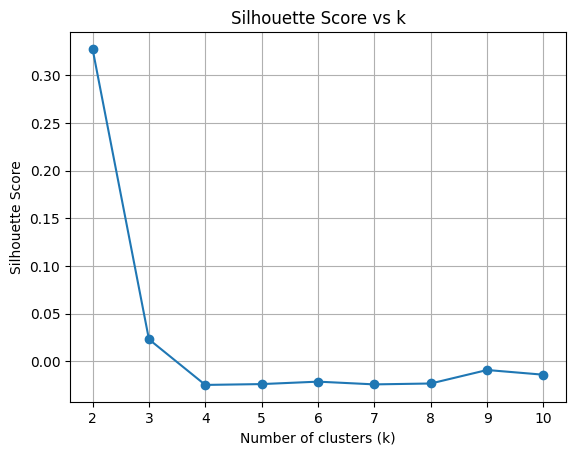

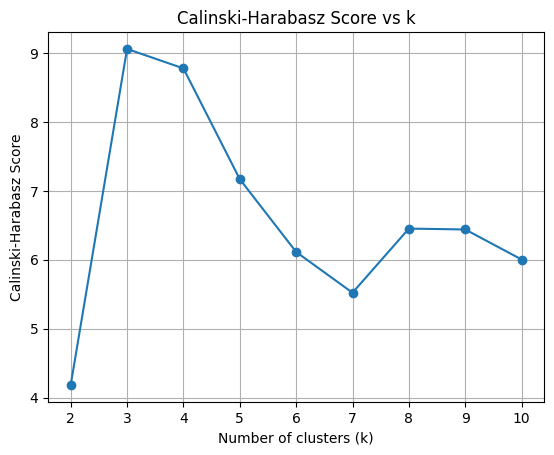

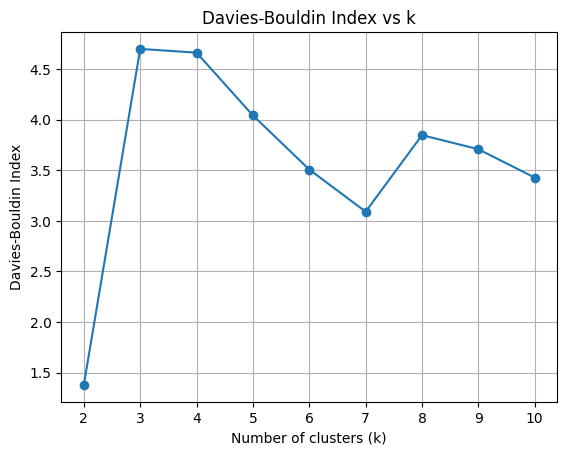

In [23]:
# A6
def plot_scores(k_values, sil_scores, ch_scores, db_scores):

    # Silhouette Score
    plt.figure()
    plt.plot(k_values, sil_scores, marker='o')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.title("Silhouette Score vs k")
    plt.grid(True)
    plt.show()

    # Calinski–Harabasz Score
    plt.figure()
    plt.plot(k_values, ch_scores, marker='o')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Calinski-Harabasz Score")
    plt.title("Calinski-Harabasz Score vs k")
    plt.grid(True)
    plt.show()

    # Davies–Bouldin Index
    plt.figure()
    plt.plot(k_values, db_scores, marker='o')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Davies-Bouldin Index")
    plt.title("Davies-Bouldin Index vs k")
    plt.grid(True)
    plt.show()


# Range of k values
k_values = range(2, 11)

silhouette_scores = []
ch_scores = []
db_scores = []

for k in k_values:
    kmeans = apply_kmeans(X_scaled, n_clusters=k)
    sil, ch, db = evaluate_clustering(X_scaled, kmeans.labels_)
    
    silhouette_scores.append(sil)
    ch_scores.append(ch)
    db_scores.append(db)

plot_scores(k_values, silhouette_scores, ch_scores, db_scores)

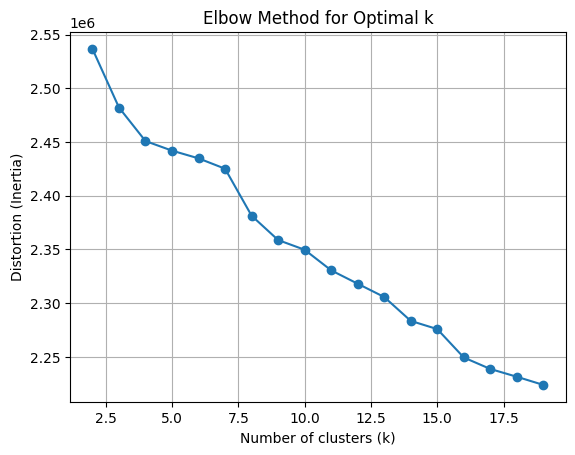

In [24]:
# A7
def elbow_method(X_scaled, k_range=range(2, 20)):
    """Computes distortions (inertia) for different k values"""
    distortions = []

    for k in k_range:
        kmeans = apply_kmeans(X_scaled, n_clusters=k, random_state=0)  # FIXED
        distortions.append(kmeans.inertia_)

    return distortions


def plot_elbow(k_values, distortions):
    plt.figure()
    plt.plot(k_values, distortions, marker='o')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Distortion (Inertia)")
    plt.title("Elbow Method for Optimal k")
    plt.grid(True)
    plt.show()


k_values = range(2, 20)
distortions = elbow_method(X_scaled, k_values)
plot_elbow(k_values, distortions)